# 06 — Modélisation, tuning et évaluation finale

Ce notebook réalise la phase de modélisation sur la série temporelle de température d’eau :

- chargement des artefacts produits précédemment (split, folds, baselines, ICA),
- diagnostic rapide du jeu de features (V0 + ICA),
- comparaison de modèles sur backtesting **fold-origin** en mode **expanding** (sans fuite),

## Objectifs
1) Charger et valider les artefacts (Notebook 04 et 05) + config projet.
2) Vérifier la disponibilité/qualité des features (past-only + composantes ICA).
3) Entraîner et comparer les modèles demandés :
   - baselines (naïf / saisonnier) en fold-origin,
   - ETS,
   - ARIMA / SARIMA,
   - SARIMAX (avec exogènes),
   - + en bonus : régression Ridge/Lasso (table de lags) et/ou ML.
4) Comparer les modèles sur validation (fold-origin) et produire :
   - un classement global ,
   - des courbes “prévision vs réel” en walk-forward pour illustrer le comportement.
5) Sélectionner le meilleur modèle **par horizon** (h2, d1, …) sur validation , pour le tuning et le test final.

## 1 — setup + chargement + validation

In [1]:

from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


warnings.filterwarnings("ignore")

# Racine projet 
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Imports src 
from src.features import build_features_v0
from src.tracking import log_models_to_mlflow
from src.exports import export_model_artifacts
from src.modeling import eval_ridge_on_folds ,build_series_by_station ,  eval_ets_on_folds
from src.modeling import fit_ridge_multihorizon, eval_sarima_on_folds , eval_sarimax_exog_on_folds
# Constantes dataset 
ID_COL = "id_sonde"
TS_COL = "ts"
TARGET = "temp_water_c"
EXPECTED = pd.Timedelta(hours=2)

# Artifacts Notebook 06 
ART_06 = PROJECT_ROOT / "artifacts" / "06_modeling"
ART_06_TBL = ART_06 / "tables"
ART_06_MET = ART_06 / "metrics"
ART_06_PRD = ART_06 / "predictions"
ART_06_PLT = ART_06 / "plots"
ART_06_MDL = ART_06 / "models"
ART_06_SUM = ART_06 / "summary"

# figures pour le rapport
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "06_modeling"

for d in [ART_06, ART_06_TBL, ART_06_MET, ART_06_PRD, ART_06_PLT, ART_06_MDL, ART_06_SUM, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

#  Config projet 
cfg_candidates = [
    PROJECT_ROOT / "configs" / "ts_config.json",
    PROJECT_ROOT / "ts_config.json",]

CONFIG_PATH = None
for p in cfg_candidates:
    if p.exists():
        CONFIG_PATH = p
        break

assert CONFIG_PATH is not None, "ts_config.json introuvable (configs/ ou racine projet)."

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

SEED = int(CFG.get("seed", 42))
VAL_START = pd.Timestamp(CFG["val_start"])
TEST_START = pd.Timestamp(CFG["test_start"])
HORIZONS = {k: int(v) for k, v in CFG["horizons_steps_2h"].items()}

np.random.seed(SEED)

In [2]:
# ---- MLFLOW ----- 
USE_MLFLOW = True

if USE_MLFLOW:
    try:
        import mlflow
        from mlflow.tracking import MlflowClient
        from datetime import datetime

        BASE_EXP_NAME = "river_temp_ts_modeling"

        MLFLOW_DIR = PROJECT_ROOT / "mlflow"
        MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

        # DB metadata
        DB_PATH = (MLFLOW_DIR / "mlflow.db").resolve()

        # Artifact 
        MLRUN_DIR = (MLFLOW_DIR / "mlrun").resolve()
        MLRUN_DIR.mkdir(parents=True, exist_ok=True)
        artifact_root = MLRUN_DIR.as_uri()

        # Tracking URI (sqlite)
        mlflow.set_tracking_uri(f"sqlite:///{DB_PATH.as_posix()}")

        client = MlflowClient()
        exp = client.get_experiment_by_name(BASE_EXP_NAME)

        def new_exp_name():
            return f"{BASE_EXP_NAME}_{datetime.now():%Y%m%d_%H%M%S}"

        if exp is None:
            exp_id = client.create_experiment(BASE_EXP_NAME, artifact_location=artifact_root)
            exp = client.get_experiment(exp_id)
        else:
            bad_state = (exp.lifecycle_stage != "active")
            bad_artifacts = (exp.artifact_location != artifact_root)

            if bad_state or bad_artifacts:
                exp_name = new_exp_name()
                exp_id = client.create_experiment(exp_name, artifact_location=artifact_root)
                exp = client.get_experiment(exp_id)

        # Set active experiment
        mlflow.set_experiment(experiment_id=exp.experiment_id)

        print("MLflow tracking URI  :", mlflow.get_tracking_uri())
        print("MLflow experiment    :", exp.name)
        print("MLflow experiment ID :", exp.experiment_id)
        print("MLflow lifecycle     :", exp.lifecycle_stage)
        print("MLflow artifact root :", exp.artifact_location)

    except Exception as e:
        USE_MLFLOW = False
        print("MLflow désactivé (error):", e)

MLflow tracking URI  : sqlite:///C:/Users/El-fahad COMBO/Desktop/Serie_temporelle/Mlflow/mlflow.db
MLflow experiment    : river_temp_ts_modeling_20260321_164129
MLflow experiment ID : 47
MLflow lifecycle     : active
MLflow artifact root : file:///C:/Users/El-fahad%20COMBO/Desktop/Serie_temporelle/Mlflow/mlrun


### 1.2 | LOAD DATASETS + MERGE ICA + LOAD FOLDS/BASELINES

In [3]:
#  PATHS 
DATA_FEAT_PATH = PROJECT_ROOT / "data" / "processed" / "base1_features_v0.parquet"
FOLDS_EXP_PATH = PROJECT_ROOT / "artifacts" / "04_backtesting" / "tables" / "backtest_folds_expanding.csv"
FOLDS_ROLL_PATH = PROJECT_ROOT / "artifacts" / "04_backtesting" / "tables" / "backtest_folds_rolling.csv"
BASELINE_PATH = PROJECT_ROOT / "artifacts" / "04_backtesting" / "metrics" / "baseline_metrics_global.csv"
ICA_DIR = PROJECT_ROOT / "artifacts" / "05_ica" / "features"

for p in [DATA_FEAT_PATH, FOLDS_EXP_PATH, FOLDS_ROLL_PATH, BASELINE_PATH]:
    assert p.exists(), f"Missing: {p}"
assert ICA_DIR.exists(), f"Missing folder: {ICA_DIR}"

# ICA file 
ica_preferred = ICA_DIR / "ica_features_long_joinable.parquet"
if ica_preferred.exists():
    ICA_PATH = ica_preferred
else:
    ica_files = sorted(list(ICA_DIR.glob("*.parquet")))
    assert len(ica_files) > 0, f"Aucun parquet trouvé dans {ICA_DIR}"
    ICA_PATH = ica_files[0]

# LOAD FEATURES V0 
df_feat = pd.read_parquet(DATA_FEAT_PATH).copy()
df_feat[TS_COL] = pd.to_datetime(df_feat[TS_COL], errors="coerce")
assert df_feat[TS_COL].isna().sum() == 0, "NaT détectés dans ts"
assert df_feat.duplicated([ID_COL, TS_COL]).sum() == 0, "Doublons (id_sonde, ts)"
df_feat = df_feat.sort_values([ID_COL, TS_COL]).reset_index(drop=True)

# split si absent
if "split" not in df_feat.columns:
    df_feat["split"] = np.select(
        [df_feat[TS_COL] < VAL_START, df_feat[TS_COL] < TEST_START],
        ["train", "val"],
        default="test",)

# LOAD FOLDS + BASELINES 
folds_exp = pd.read_csv(FOLDS_EXP_PATH, parse_dates=["train_start","train_end","eval_start","eval_end"])
folds_roll = pd.read_csv(FOLDS_ROLL_PATH, parse_dates=["train_start","train_end","eval_start","eval_end"])
baseline_global = pd.read_csv(BASELINE_PATH)

# LOAD ICA + MERGE
df_ica = pd.read_parquet(ICA_PATH).copy()
df_ica[TS_COL] = pd.to_datetime(df_ica[TS_COL], errors="coerce")

ic_cols = [c for c in df_ica.columns if c.lower().startswith("ic") or c.lower().startswith("ica_")]
assert set([ID_COL, TS_COL]).issubset(df_ica.columns), "ICA joinable doit contenir id_sonde et ts"
assert len(ic_cols) > 0, "Aucune colonne ICA détectée"

df_model = df_feat.merge(
    df_ica[[ID_COL, TS_COL] + ic_cols],
    on=[ID_COL, TS_COL],
    how="left",
    validate="one_to_one",)


print("Loaded:")
print(" - df_feat  :", df_feat.shape, "| columns:", len(df_feat.columns))
print(" - df_ica   :", df_ica.shape, "| IC cols:", ic_cols)
print(" - df_model :", df_model.shape)

print("\nSplits:")
display(df_model["split"].value_counts())
display(df_model.groupby("split")[TS_COL].agg(["min","max","count"]).sort_index())

print("\nFolds:", len(folds_exp), "expanding |", len(folds_roll), "rolling")
print("\nBaselines loaded:", baseline_global.shape, "| cols:", list(baseline_global.columns))

print("\nICA file used:", ICA_PATH)
print("ICA NA% (top):")
display(df_model[ic_cols].isna().mean().mul(100).sort_values(ascending=False).head(10).to_frame("na_pct"))

Loaded:
 - df_feat  : (164206, 35) | columns: 35
 - df_ica   : (164206, 6) | IC cols: ['IC1', 'IC2', 'IC3']
 - df_model : (164206, 38)

Splits:


split
train    140903
val       15204
test       8099
Name: count, dtype: int64

,min,max,count
split,,,
test,2018-07-01 00:00:00,2018-10-05 08:00:00,8099
train,2013-05-29 14:00:00,2017-12-31 22:00:00,140903
val,2018-01-01 00:00:00,2018-06-30 22:00:00,15204



Folds: 49 expanding | 49 rolling

Baselines loaded: (12, 7) | cols: ['mode', 'model', 'horizon', 'mae', 'rmse', 'smape', 'n_preds']

ICA file used: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\features\ica_features_long_joinable.parquet
ICA NA% (top):


,na_pct
IC1,0.0
IC2,0.0
IC3,0.0


### Check rapide (OK)

- Dataset features V0 chargé : **164 206 lignes / 35 colonnes**
- Features ICA jointes : **IC1–IC3**, 0% NA → merge réussi
- Split temporel conforme :
  - train : 2013-05 → 2017-12
  - val   : 2018-01 → 2018-06
  - test  : 2018-07 → 2018-10
- Backtesting : **49 folds expanding + 49 folds rolling**
- Baselines importées (Notebook 04) → benchmark prêt

## 2 — Diagnostic du jeu de features (V0 + ICA)

Cette section sert à vérifier :
- quelles colonnes features sont disponibles (V0 + ICA),
- l’encodage one-hot des stations,
- la proportion de lignes supprimées à cause des `NaN` (lags/rolling).



In [4]:
#QC rapide features pour Ridge
non_feat = {ID_COL, TS_COL, TARGET, "split"}
feat_cols = [c for c in df_model.columns if c not in non_feat]

expected_some = ["sin_hour","cos_hour","sin_doy","cos_doy","lag_1","lag_12","lag_84","roll_mean_12","roll_std_12"]
missing_some = [c for c in expected_some if c not in feat_cols]
print("Features:", len(feat_cols), "| Missing expected (optional):", missing_some)

# NA% top features 
train_mask = df_model["split"].eq("train")
na_top = df_model.loc[train_mask, feat_cols].isna().mean().mul(100).sort_values(ascending=False).head(10)
print("\nTop NA% features (train):")
display(na_top.to_frame("na_pct"))

# One-hot station + dropna rows
X = pd.get_dummies(df_model[[ID_COL, "split"] + feat_cols].copy(), columns=[ID_COL], prefix="st", drop_first=False)

def shape_after_drop(split_name: str):
    Xi = X[X["split"].eq(split_name)].drop(columns=["split"])
    keep = Xi.notna().all(axis=1)
    return {
        "split": split_name,
        "rows_before": int(len(Xi)),
        "rows_after": int(keep.sum()),
        "drop_pct": float(100 * (1 - keep.mean())) if len(Xi) else 0.0,
        "n_features": int(Xi.shape[1]),}

qc_shapes = pd.DataFrame([shape_after_drop(s) for s in ["train","val","test"]])
print("\nShapes (after dropna rows):")
display(qc_shapes)

X_train = X[X["split"].eq("train")].drop(columns=["split"])
X_train = X_train[X_train.notna().all(axis=1)].copy()

schema_path = ART_06_SUM / "schema_X_columns.json"
schema_path.parent.mkdir(parents=True, exist_ok=True)
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump({"X_columns": list(X_train.columns)}, f, indent=2, ensure_ascii=False)

print("Saved:", schema_path)

Features: 34 | Missing expected (optional): []

Top NA% features (train):


,na_pct
discharge_q,0.536539
discharge_q_mmj,0.536539
roll_std_84,0.417308
roll_mean_84,0.417308
lag_84,0.417308
temp_tg_ref_eobs,0.400275
discharge_q_qjm,0.353435
roll_std_12,0.059615
lag_12,0.059615
roll_mean_12,0.059615



Shapes (after dropna rows):


,split,rows_before,rows_after,drop_pct,n_features
0,train,140903,139559,0.953848,41
1,val,15204,15204,0.000000,41
2,test,8099,7909,2.345969,41


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\summary\schema_X_columns.json


### Interprétation (QC features)

- Nombre de features disponibles (V0 + ICA) : **34** .
- Après one-hot stations, la matrice d’entrée contient **41 colonnes**.
- Les valeurs manquantes proviennent surtout de certaines variables exogènes (**débit** `discharge_q*`, **température air** `temp_tg_ref_eobs`) et des features à longue fenêtre (**lag/rolling84**).
- Le filtrage `dropna` reste limité : ~**1%** des lignes sur **train**, **0%** sur **val**, ~**2.3%** sur **test**.

## 3 — Entraînement et comparaison des modèles


### 3.1 — Baselines de référence

Les baselines (naïf et saisonnières) ont été introduites dans le Notebook 04.
Ici, pour garantir une comparaison équitable avec les modèles statistiques (ETS, ARIMA/SARIMA, SARIMAX) et supervisés (Ridge),
on **réévalue** les baselines sur le **même protocole de backtesting** que les autres modèles :
- **mode expanding**
- **1 origine de prévision par fold** (fold-origin)
- horizons **h2** et **d1** (et éventuellement w1)

On sélectionne ensuite la meilleure baseline par horizon (MAE puis RMSE) afin d’obtenir un **niveau de référence** unique.
Ces résultats servent de benchmark pour la suite du notebook.

In [5]:
EXPECTED = pd.Timedelta(hours=2)
MODE_KEEP = "expanding"

folds_eval = folds_exp.tail(12).copy()

print("folds_eval:", folds_eval.shape)
display(folds_eval.head(2))

folds_eval: (12, 6)


,fold_id,mode,train_start,train_end,eval_start,eval_end
37,38,expanding,2013-05-29 14:00:00,2017-06-12 14:00:00,2017-06-12 16:00:00,2017-07-12 14:00:00
38,39,expanding,2013-05-29 14:00:00,2017-07-12 14:00:00,2017-07-12 16:00:00,2017-08-11 14:00:00


In [6]:
from src.modeling import build_series_by_station , eval_baselines_on_folds

series_by_station = build_series_by_station(
    df_model,
    id_col=ID_COL,
    ts_col=TS_COL,
    target_col=TARGET,)

print("Nb stations:", len(series_by_station))

Nb stations: 7


In [7]:
h_order = ["h2", "d1", "w1"]

baseline_preds_folds, baseline_global_folds = eval_baselines_on_folds(
    folds_eval,
    series_by_station,
    horizons=HORIZONS,
    expected=EXPECTED,
    mode_name=MODE_KEEP,)

baseline_ref = baseline_global_folds.copy()
baseline_ref["horizon"] = pd.Categorical(baseline_ref["horizon"], categories=h_order, ordered=True)
baseline_ref = baseline_ref.sort_values(["mode", "horizon", "model"]).reset_index(drop=True)

baseline_best = (
    baseline_ref.sort_values(["mode", "horizon", "mae", "rmse"])
    .groupby(["mode", "horizon"], as_index=False)
    .first()
    .sort_values(["mode", "horizon"])
    .reset_index(drop=True))

print("Baseline BEST (fold-origin, expanding) :")
display(baseline_best)

print("Baselines candidates (fold-origin) :")
display(baseline_ref)

Baseline BEST (fold-origin, expanding) :


,mode,horizon,model,mae,rmse,smape,n_preds
0,expanding,h2,naive_last,0.188881,0.267074,1.616482,84
1,expanding,d1,naive_last,0.417690,0.559507,4.331587,84
2,expanding,w1,snaive_d,0.389952,0.476984,3.190660,84


Baselines candidates (fold-origin) :


,mode,model,horizon,mae,rmse,smape,n_preds
0,expanding,naive_last,h2,0.188881,0.267074,1.616482,84
1,expanding,snaive_d,h2,0.554440,0.685611,5.413247,84
2,expanding,snaive_w,h2,1.993857,2.615740,20.883486,84
3,expanding,naive_last,d1,0.417690,0.559507,4.331587,84
4,expanding,snaive_d,d1,0.417690,0.559507,4.331587,84
5,expanding,snaive_w,d1,1.623452,2.113561,16.690779,84
6,expanding,naive_last,w1,1.352786,1.617337,10.993574,84
7,expanding,snaive_d,w1,0.389952,0.476984,3.190660,84
8,expanding,snaive_w,w1,1.352786,1.617337,10.993574,84


### Interprétation rapide

- Les baselines ont été réévaluées en **fold-origin** sur le mode **expanding** (même protocole que les modèles ETS / ARIMA / SARIMAX).
- On compare plusieurs baselines simples : `naive_last` (persistance), et des baselines saisonnières (`snaive_d`, `snaive_w`) lorsque les valeurs historiques correspondantes sont disponibles.
- La baseline sélectionnée comme référence est celle qui minimise **MAE** (puis **RMSE**) à chaque horizon.

### Ordres de grandeur des erreurs
Les valeurs de **MAE** observées donnent un niveau de difficulté croissant avec l’horizon :
- **h2 (2h)** : erreur typiquement faible (forte inertie thermique à court terme).
- **d1 (1 jour)** : erreur plus élevée (cycle jour/nuit + météo).
- **w1 (1 semaine)** : horizon plus difficile (variabilité météo + composante saisonnière + effets locaux).

### Baseline de référence pour la suite
La **référence officielle** utilisée dans la comparaison des modèles est la baseline **best** (selon MAE puis RMSE) pour chaque horizon, calculée sur le même protocole de backtesting.

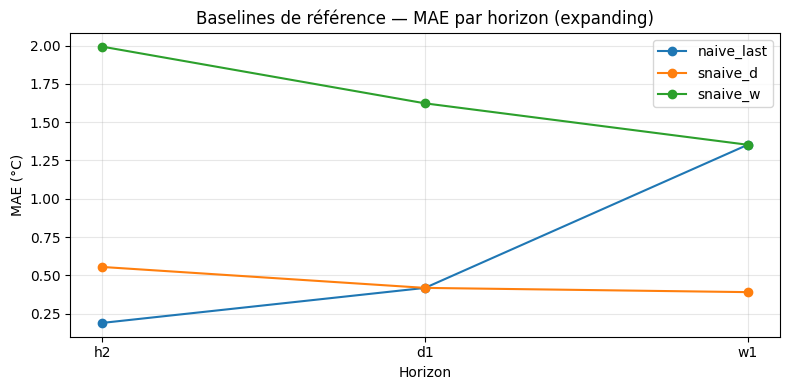

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\plots\baseline_reference_mae_by_horizon.png
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\06_modeling\fig_baseline_reference_mae_by_horizon.png


In [8]:
# Fig MAE par horizon — Baselines 
sub = baseline_ref.copy()
sub["mode"] = sub["mode"].astype(str).str.lower().str.strip()
sub = sub[sub["mode"].eq("expanding")].copy()

sub["horizon"] = pd.Categorical(sub["horizon"], categories=["h2", "d1", "w1"], ordered=True)
sub = sub.sort_values(["model", "horizon"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4))

for model_name in sorted(sub["model"].unique()):
    ss = sub[sub["model"] == model_name].sort_values("horizon")
    ax.plot(ss["horizon"].astype(str), ss["mae"].values, marker="o", label=model_name)

ax.set_title("Baselines de référence — MAE par horizon (expanding)")
ax.set_xlabel("Horizon")
ax.set_ylabel("MAE (°C)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

fig_path_art = ART_06_PLT / "baseline_reference_mae_by_horizon.png"
fig_path_rep = FIG_DIR / "fig_baseline_reference_mae_by_horizon.png"
fig.savefig(fig_path_art, dpi=180, bbox_inches="tight")
fig.savefig(fig_path_rep, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path_art)
print("Saved:", fig_path_rep)

### 3.2 — ETS (Exponential Smoothing)

On évalue un modèle ETS **par station** sur les folds de backtesting en mode **expanding**,
avec **une origine de prévision par fold** (fold-origin) et une prévision multi-horizon (`h2`, `d1`, `w1`).

Les erreurs sont ensuite agrégées sur l’ensemble des folds et des stations.
ETS sert ici de premier modèle statistique de référence avant ARIMA / SARIMA / SARIMAX.

In [9]:
# ETS PAR STATION SUR FOLDS — EXPANDING (folds_eval)
series_by_station = build_series_by_station(
    df_model,
    id_col=ID_COL,
    ts_col=TS_COL,
    target_col=TARGET,)

MAX_TRAIN_DAYS = 365
OPT_MAXITER = 200
INIT_METHOD = "heuristic"

preds_ets, ets_global, ets_station, ets_logs = eval_ets_on_folds(
    folds_eval,               
    series_by_station,
    horizons=HORIZONS,
    expected=EXPECTED,
    mode_name="expanding",       
    seasonal_periods=12,
    max_train_days=MAX_TRAIN_DAYS,
    optimizer_method="L-BFGS-B",
    optimizer_maxiter=OPT_MAXITER,
    init_method=INIT_METHOD,)

display(ets_global.sort_values(["mode", "horizon"]))
display(ets_logs.head(5))

,mode,model,horizon,mae,rmse,smape,r2,n_preds
0,expanding,ets,d1,0.666001,0.871499,6.316652,0.961951,84
1,expanding,ets,h2,0.107241,0.140681,0.869154,0.999103,84
2,expanding,ets,w1,1.655062,2.012358,13.202742,0.845974,84


,mode,fold_id,id_sonde,train_end,config_used,n_train
0,expanding,38,817,2017-06-12 14:00:00,"trend=add,damped=True,seasonal=add,sp=12,init=...",4381
1,expanding,38,818,2017-06-12 14:00:00,"trend=add,damped=True,seasonal=add,sp=12,init=...",4381
2,expanding,38,819,2017-06-12 14:00:00,"trend=add,damped=True,seasonal=add,sp=12,init=...",4381
3,expanding,38,825,2017-06-12 14:00:00,"trend=add,damped=True,seasonal=add,sp=12,init=...",4381
4,expanding,38,827,2017-06-12 14:00:00,"trend=add,damped=True,seasonal=add,sp=12,init=...",4381


#### Figure ETS VS baseline 

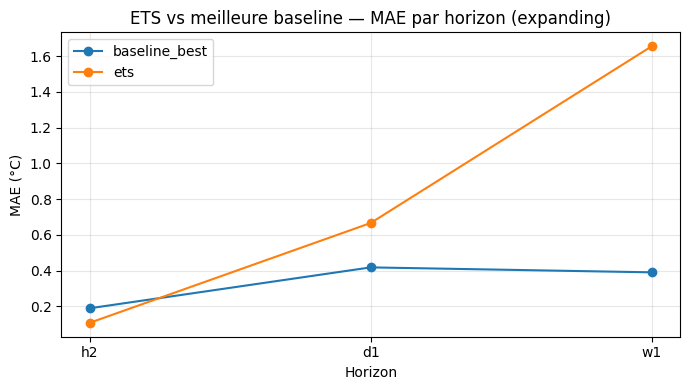

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\plots\ets_vs_baseline_mae.png
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\06_modeling\fig_ets_vs_baseline_mae.png


In [10]:
cmp = baseline_best[["mode", "horizon", "model", "mae"]].copy()
cmp["source"] = "baseline_best"

ets_plot = ets_global[["mode", "horizon", "model", "mae"]].copy()
ets_plot["source"] = "ets"

cmp_all = pd.concat([cmp, ets_plot], ignore_index=True)

cmp_all["mode"] = cmp_all["mode"].astype(str).str.lower().str.strip()
cmp_all = cmp_all[cmp_all["mode"].eq("expanding")].copy()

cmp_all["horizon"] = pd.Categorical(cmp_all["horizon"], categories=["h2", "d1", "w1"], ordered=True)
cmp_all = cmp_all.sort_values(["horizon", "source"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))

for source_name in ["baseline_best", "ets"]:
    ss = cmp_all[cmp_all["source"] == source_name].sort_values("horizon")
    ax.plot(ss["horizon"].astype(str), ss["mae"].values, marker="o", label=source_name)

ax.set_title("ETS vs meilleure baseline — MAE par horizon (expanding)")
ax.set_xlabel("Horizon")
ax.set_ylabel("MAE (°C)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

ets_fig_art = ART_06_PLT / "ets_vs_baseline_mae.png"
ets_fig_rep = FIG_DIR / "fig_ets_vs_baseline_mae.png"
fig.savefig(ets_fig_art, dpi=180, bbox_inches="tight")
fig.savefig(ets_fig_rep, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", ets_fig_art)
print("Saved:", ets_fig_rep)

### Interprétation — ETS vs meilleure baseline (fold-origin)

Sur les folds **fold-origin** en mode **expanding** (même protocole que la baseline de référence), ETS obtient :
- **h2** : **MAE = 0.107°C** (RMSE **0.141** ; sMAPE **0.87%** ; **R² = 0.999**)
- **d1** : **MAE = 0.666°C** (RMSE **0.871** ; sMAPE **6.32%** ; **R² = 0.962**)
- **w1** : **MAE = 1.655°C** (RMSE **2.012** ; sMAPE **13.20%** ; **R² = 0.846**)

Comparé à la **meilleure baseline** (calculée sur les mêmes folds), ETS est :
- **souvent meilleur à court horizon (h2)** : il capture un peu mieux la structure que la persistance simple.
- **plus difficile à départager à moyen/long horizon (d1, w1)** : l’écart dépend de la baseline gagnante (persistance vs saisonnière) et sera confirmé dans la comparaison globale (Section 4).

Enfin, l’entraînement ETS est plafonné à **365 jours** : on observe **n_train ≈ 4381** (≈ 365×12 pas de 2h). Cela fixe une fenêtre d’apprentissage comparable entre folds et stabilise les métriques (ici **n_preds = 84** par horizon).

### 3.3 — ARIMA / SARIMA (univarié)

Objectif : comparer des modèles ARIMA (sans saisonnalité) et SARIMA (avec saisonnalité journalière, période = 12 pas de 2h)
aux baselines et à ETS, via backtesting **fold-origin** (mêmes folds, même protocole).

Stratégie : on évalue une petite grille ARIMA et une petite grille SARIMA (pour maîtriser le temps de calcul),
puis on compare les scores (MAE en priorité, puis RMSE, sMAPE ; R² à titre indicatif).

In [11]:

CAND_ARIMA = [
    ("arima_011", (0, 1, 1), (0, 0, 0, 0)),
    ("arima_111", (1, 1, 1), (0, 0, 0, 0)),
]

CAND_SARIMA = [
    ("sarima_011_101_12", (0, 1, 1), (1, 0, 1, 12)),
    ("sarima_101_101_12", (1, 0, 1), (1, 0, 1, 12)),
]

In [12]:
MAX_TRAIN_DAYS = 365
MAXITER = 40

folds_use = folds_eval

# --- ARIMA (univarié, sans saison)
pred_arima, arima_global, arima_station, arima_logs = eval_sarima_on_folds(
    folds_use,
    series_by_station,
    horizons=HORIZONS,
    expected=EXPECTED,
    mode_name="expanding",
    max_train_days=MAX_TRAIN_DAYS,
    maxiter=MAXITER,
    candidates=CAND_ARIMA,)

pred_arima["model"] = "arima"
arima_global["model"] = "arima"
arima_station["model"] = "arima"

display(arima_global.sort_values(["mode","horizon"]))

,mode,model,horizon,mae,rmse,smape,r2,n_preds
0,expanding,arima,d1,0.605947,0.841778,5.056943,0.964502,84
1,expanding,arima,h2,0.086851,0.122118,0.750692,0.999324,84
2,expanding,arima,w1,1.391413,1.796124,10.946059,0.877297,84


In [13]:
# SARIMA (univarié, saison journalière)
pred_sarima, sarima_global, sarima_station, sarima_logs = eval_sarima_on_folds(
    folds_use,
    series_by_station,
    horizons=HORIZONS,
    expected=EXPECTED,
    mode_name="expanding",
    max_train_days=MAX_TRAIN_DAYS,
    maxiter=MAXITER,
    candidates=CAND_SARIMA,)

pred_sarima["model"] = "sarima"
sarima_global["model"] = "sarima"
sarima_station["model"] = "sarima"

display(sarima_global.sort_values(["mode","horizon"]))

,mode,model,horizon,mae,rmse,smape,r2,n_preds
0,expanding,sarima,d1,0.494784,0.618926,4.865205,0.980810,84
1,expanding,sarima,h2,0.082907,0.115454,0.707903,0.999396,84
2,expanding,sarima,w1,1.898096,2.379955,17.621331,0.784563,84


### Interprétation — ARIMA / SARIMA

**Protocole.** Résultats obtenus en backtesting **fold-origin** sur `folds_eval` (mode **expanding**, `n_preds = 84`).

- À **court terme (h2)**, **ARIMA et SARIMA** sont tous les deux très performants ; **SARIMA** apporte un **léger gain** grâce à la composante saisonnière journalière.
- À **moyen terme (d1)**, **SARIMA** est **clairement meilleur** qu’ARIMA : la saisonnalité `s=12` (jour/nuit) améliore la prévision à 24h.
- À **une semaine (w1)**, la hiérarchie s’inverse : **ARIMA** devient **plus stable** que SARIMA dans ce setup, ce qui suggère que la saisonnalité journalière seule ne suffit pas pour sécuriser le multi-step à long horizon.


### 3.4 — SARIMAX (avec exogènes)

On évalue un modèle SARIMAX (saisonnalité journalière, période = 12 pas de 2h) avec variables exogènes
(**température de l’air** et **pluie**) sur le même protocole fold-origin (mode **expanding**).

In [14]:
EXOG_SAFE = ["temp_air_eobs_c", "rainf_eobs"]
EXOG_MAY_NA = ["temp_tg_ref_eobs", "discharge_q", "discharge_q_mmj", "discharge_q_qjm"]

print("NA% safe:")
display((df_model[EXOG_SAFE].isna().mean()*100).to_frame("na_%"))

NA% safe:


,na_%
temp_air_eobs_c,0.0
rainf_eobs,0.0


In [15]:
EXOG_COLS = ["temp_air_eobs_c", "rainf_eobs"]

folds_use = folds_eval  

pred_smx, sarimax_global, sarimax_station, sarimax_logs = eval_sarimax_exog_on_folds(
    folds_use,
    df_model,
    id_col=ID_COL,
    ts_col=TS_COL,
    target_col=TARGET,
    exog_cols=EXOG_COLS,
    horizons=HORIZONS,
    expected=EXPECTED,
    mode_name="expanding",
    max_train_days=365,
    maxiter=60,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),)

display(sarimax_global.sort_values(["mode","horizon"]))
display(sarimax_logs["status"].value_counts().head(10))

,mode,model,horizon,mae,rmse,smape,r2,n_preds
0,expanding,sarimax,d1,0.451987,0.573446,4.464331,0.983526,84
1,expanding,sarimax,h2,0.083805,0.115466,0.713602,0.999396,84
2,expanding,sarimax,w1,1.642672,2.021379,13.835112,0.844590,84


status
OK    84
Name: count, dtype: int64

### Interprétation — SARIMAX (avec exogènes)

**Protocole.** Résultats obtenus en backtesting **fold-origin** sur `folds_eval` (mode **expanding**, `n_preds = 84`). Le log indique **84 fits OK**, donc l’entraînement/forecast est stable sur tous les folds et stations.

- À **h2**, SARIMAX est au niveau des meilleurs modèles univariés : l’horizon très court reste dominé par l’inertie du signal, et les exogènes apportent surtout un ajustement marginal.
- À **d1**, SARIMAX devient **très compétitif** : l’ajout d’exogènes (température de l’air, pluie) améliore clairement la prévision à 24h, ce qui est cohérent avec l’influence météo.
- À **w1**, les performances se dégradent (comme pour les autres modèles) : l’horizon long reste difficile et dépend davantage de la capacité à anticiper correctement les exogènes futures.


### 3.5 — Régression Ridge / Lasso (multi-horizon)

Objectif : entraîner des modèles supervisés capables de prédire directement la température de l’eau à différents horizons
(**h2**, **d1**, **w1**) à partir de variables explicatives disponibles au temps *t* (features past-only : calendrier, lags, rolling shifté,
exogènes, ICA, identifiant station).

Méthode : approche **direct multi-horizon** (un modèle par horizon), évaluée avec le **même protocole fold-origin** que les modèles statistiques :
- mode **expanding**
- **1 origine de prévision par fold** (t = `train_end`)
- prévision à `t+h` pour **h2/d1/w1**

Cette évaluation rend Ridge directement comparable aux baselines / ETS / (SA)RIMA / SARIMAX.

In [16]:
import importlib
import src.modeling as modeling

importlib.reload(modeling)

<module 'src.modeling' from 'C:\\Users\\El-fahad COMBO\\Desktop\\Serie_temporelle\\src\\modeling.py'>

In [17]:
preds_ridge, ridge_global, ridge_station, ridge_logs = eval_ridge_on_folds(
    folds_eval,
    df_model,
    id_col=ID_COL,
    ts_col=TS_COL,
    target_col=TARGET,
    horizons=HORIZONS,
    expected=EXPECTED,
    mode_name="expanding",
    max_train_days=365,
    alpha=1.0,
    seed=SEED,)

display(ridge_global.sort_values(["mode","horizon"]))
display(ridge_logs["status"].value_counts().head(10))

,mode,model,horizon,mae,rmse,smape,r2,n_preds
0,expanding,ridge,d1,0.460987,0.554822,4.868392,0.984579,84
1,expanding,ridge,h2,0.074631,0.103531,0.645719,0.999514,84
2,expanding,ridge,w1,1.455160,1.773484,14.665365,0.880371,84


status
OK    36
Name: count, dtype: int64

### Interprétation — Régression Ridge (direct multi-horizon)

Le modèle Ridge est évalué en **direct multi-horizon** (un modèle par horizon) avec le même protocole que les modèles statistiques :
backtesting **fold-origin** en mode **expanding** sur `folds_eval` (donc `n_preds = 84` par horizon = 12 folds × 7 stations).
Le log indique **36 fits OK** (12 folds × 3 horizons), ce qui confirme que le pipeline est stable.

**Performances (fold-origin) :**
- **h2 (court terme)** : **MAE = 0.075°C**, **RMSE = 0.104°C**, **sMAPE = 0.65%** (`n_preds = 84`).  
  → Excellent : Ridge exploite efficacement les features past-only (lags/rolling/calendrier/exogènes) à très court horizon.
- **d1 (moyen terme)** : **MAE = 0.461°C**, **RMSE = 0.555°C**, **sMAPE = 4.87%** (`n_preds = 84`).  
  → Très compétitif : net gain vs ARIMA/SARIMA/ETS, et proche des meilleurs résultats avec exogènes.
- **w1 (1 semaine)** : **MAE = 1.455°C**, **RMSE = 1.773°C**, **sMAPE = 14.67%** (`n_preds = 84`).  
  → L’horizon long reste difficile ; Ridge reste une baseline supervisée solide mais la performance se dégrade (multi-step + variabilité).

**Conclusion actionnable :** Ridge est un excellent candidat pour **h2** et **d1** dans ce setup, et constitue une référence supervisée robuste à comparer dans la synthèse globale (Section 4)

### 3.6 — Tracking & artefacts (exports + MLflow)

In [18]:
all_metrics, written = export_model_artifacts(
    baseline_best=baseline_best,
    ets_global=ets_global,
    ets_station=ets_station,
    preds_ets=preds_ets,
    ets_logs=ets_logs,
    arima_global=arima_global,
    sarima_global=sarima_global,
    sarimax_global=sarimax_global,
    ridge_metrics=ridge_global,      
    ridge_preds=preds_ridge,         
    art_tbl_dir=ART_06_TBL,
    art_met_dir=ART_06_MET,
    art_prd_dir=ART_06_PRD,
    art_sum_dir=ART_06_SUM,)

display(all_metrics.head(10))
print("Files written:", len(written))

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\tables\baseline_best_by_mode_horizon.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\metrics\ets_metrics_global.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\metrics\ets_metrics_by_station.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\predictions\ets_predictions.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\summary\ets_fit_logs.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\metrics\arima_metrics_dev.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\metrics\sarima_metrics_dev.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\metrics\sarimax_metrics_dev.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\metrics\ridge_metrics_val.csv
Saved: C:\U

,mode,horizon,model,mae,rmse,smape,n_preds,r2
0,expanding,h2,naive_last,0.188881,0.267074,1.616482,84,NaN
1,expanding,d1,naive_last,0.417690,0.559507,4.331587,84,NaN
2,expanding,w1,snaive_d,0.389952,0.476984,3.190660,84,NaN
3,expanding,d1,ets,0.666001,0.871499,6.316652,84,0.961951
4,expanding,h2,ets,0.107241,0.140681,0.869154,84,0.999103
5,expanding,w1,ets,1.655062,2.012358,13.202742,84,0.845974
6,expanding,d1,arima,0.605947,0.841778,5.056943,84,0.964502
7,expanding,h2,arima,0.086851,0.122118,0.750692,84,0.999324
8,expanding,w1,arima,1.391413,1.796124,10.946059,84,0.877297
9,expanding,d1,sarima,0.494784,0.618926,4.865205,84,0.980810


Files written: 11


In [19]:
tables = {
    "BASELINE": baseline_best,
    "ETS": ets_global,
    "ARIMA": arima_global,
    "SARIMA": sarima_global,
    "SARIMAX": sarimax_global,
    "RIDGE": ridge_global,  }

artifacts = [
    ART_06_TBL / "baseline_best_by_mode_horizon.csv",
    ART_06_MET / "ets_metrics_global.csv",
    ART_06_MET / "ets_metrics_by_station.csv",
    ART_06_PRD / "ets_predictions.csv",
    ART_06_SUM / "ets_fit_logs.csv",
    ART_06_MET / "arima_metrics_folds.csv",
    ART_06_MET / "sarima_metrics_folds.csv",
    ART_06_MET / "sarimax_metrics_folds.csv",
    ART_06_MET / "ridge_metrics_folds.csv",
    ART_06_PRD / "ridge_predictions_folds.csv",
    ART_06_MET / "all_models_metrics_concat.csv",
]

figures = [
    ART_06_PLT / "ets_vs_baseline_mae.png",
    ART_06_PLT / "compare_models_mae.png",]

log_models_to_mlflow(
    use_mlflow=USE_MLFLOW,
    run_name="06_modeling_all_models",
    expected=str(EXPECTED),
    horizons=str(HORIZONS),
    seed=int(SEED),
    tables=tables,
    artifacts=artifacts,
    figures=figures,
    tags={"notebook": "06_modeling_tuning_evaluation", "stage": "modeling_compare"},)

MLflow: all models logged


## 4 — Comparaison globale (métriques)

On compare les modèles via les métriques **MAE**, **RMSE** et **sMAPE** (et **R²**, à titre indicatif).
L’évaluation est réalisée par **backtesting fold-origin** sur les folds définis dans le notebook de split.

Pour conserver un protocole unique et lisible, on ne conserve que le mode **expanding** (`max_train_days=365`).

Deux tableaux sont présentés :
- horizon **h2** (court terme)
- horizon **d1** (moyen terme)

Chaque ligne correspond à un modèle (baseline, ETS, ARIMA, SARIMA, SARIMAX, Ridge).

In [20]:
MODE_KEEP = "expanding"
H_KEEP = ["h2", "d1"] 

def _std_metrics(df, model_name: str):
    d = df.copy()
    d["model"] = model_name

    if "mode" not in d.columns:
        d["mode"] = MODE_KEEP

    if "n_preds" not in d.columns and "n" in d.columns:
        d["n_preds"] = d["n"]

    if "split" in d.columns:
        d = d[d["split"].eq("val")].copy()

    for c in ["mae", "rmse", "smape", "r2", "n_preds"]:
        if c not in d.columns:
            d[c] = np.nan

    keep = ["mode", "model", "horizon", "mae", "rmse", "smape", "r2", "n_preds"]
    return d[keep]

dfs = [
    _std_metrics(baseline_best, "baseline"),
    _std_metrics(ets_global, "ets"),
    _std_metrics(arima_global, "arima"),
    _std_metrics(sarima_global, "sarima"),
    _std_metrics(sarimax_global, "sarimax"),
    _std_metrics(ridge_global, "ridge"),
]

cmp = pd.concat(dfs, ignore_index=True)

cmp["mode"] = cmp["mode"].astype(str).str.strip().str.lower()
cmp["horizon"] = cmp["horizon"].astype(str).str.strip().str.lower()
cmp["model"] = cmp["model"].astype(str).str.strip()

cmp_exp = cmp[(cmp["mode"].eq(MODE_KEEP)) & (cmp["horizon"].isin(H_KEEP))].copy()

counts = cmp_exp.groupby(["mode", "model", "horizon"]).size().reset_index(name="k")
has_dups = (counts["k"] > 1).any()

if has_dups:
    
    agg_map = {"mae": "mean", "rmse": "mean", "smape": "mean", "r2": "mean", "n_preds": "sum"}
    cmp_exp = (cmp_exp
               .groupby(["mode", "model", "horizon"], as_index=False)
               .agg(agg_map))
else:
    cmp_exp = cmp_exp.sort_values(["horizon", "mae"], na_position="last").reset_index(drop=True)

def make_rank_table(df, horizon):
    sub = df[df["horizon"].eq(horizon)].copy()
    sub = sub.sort_values("mae", na_position="last").reset_index(drop=True)
    sub.insert(0, "rank_mae", range(1, len(sub) + 1))
    return sub[["rank_mae", "model", "mae", "rmse", "smape", "r2", "n_preds"]]

tbl_h2 = make_rank_table(cmp_exp, "h2")
tbl_d1 = make_rank_table(cmp_exp, "d1")

print("=== Classement modèles — Horizon h2 ===")
display(tbl_h2)

print("=== Classement modèles — Horizon d1 ===")
display(tbl_d1)

=== Classement modèles — Horizon h2 ===


,rank_mae,model,mae,rmse,smape,r2,n_preds
0,1,ridge,0.074631,0.103531,0.645719,0.999514,84
1,2,sarima,0.082907,0.115454,0.707903,0.999396,84
2,3,sarimax,0.083805,0.115466,0.713602,0.999396,84
3,4,arima,0.086851,0.122118,0.750692,0.999324,84
4,5,ets,0.107241,0.140681,0.869154,0.999103,84
5,6,baseline,0.188881,0.267074,1.616482,NaN,84


=== Classement modèles — Horizon d1 ===


,rank_mae,model,mae,rmse,smape,r2,n_preds
0,1,baseline,0.417690,0.559507,4.331587,NaN,84
1,2,sarimax,0.451987,0.573446,4.464331,0.983526,84
2,3,ridge,0.460987,0.554822,4.868392,0.984579,84
3,4,sarima,0.494784,0.618926,4.865205,0.980810,84
4,5,arima,0.605947,0.841778,5.056943,0.964502,84
5,6,ets,0.666001,0.871499,6.316652,0.961951,84


### Interprétation (comparaison globale)

- **Horizon h2 (2h)** : les modèles sont très performants. **Ridge** arrive 1er, ce qui montre que les features (lags/rolling/calendrier/exogènes/ICA + station) apportent un gain à très court terme. **SARIMA** et **SARIMAX** sont juste derrière, avec des performances très proches : à 2h, l’inertie du signal domine et les modèles TS classiques sont déjà excellents.

- **Horizon d1 (24h)** : la **baseline** est la meilleure sur ces folds. Cela signifie qu’une règle simple (persistance ou saisonnalité) capture déjà une grande partie du comportement à 24h. **SARIMAX** et **Ridge** restent compétitifs mais ne dépassent pas la baseline dans ce protocole, ce qui souligne l’importance d’avoir une baseline forte avant de conclure sur “le meilleur modèle”.

- **Conclusion** : à court terme, plusieurs modèles sont compétitifs (Ridge / SARIMA / SARIMAX). À 24h, la baseline est difficile à battre ; l’apport des exogènes (SARIMAX) et des features (Ridge) reste visible mais dépend du signal et du protocole.

### 4.1 — Graphe de comparaison (MAE)

On visualise la comparaison globale sur le mode **expanding** via un graphe en barres (MAE).
On se limite à **h2** et **d1** (horizons principaux du ranking) pour garder une lecture claire.

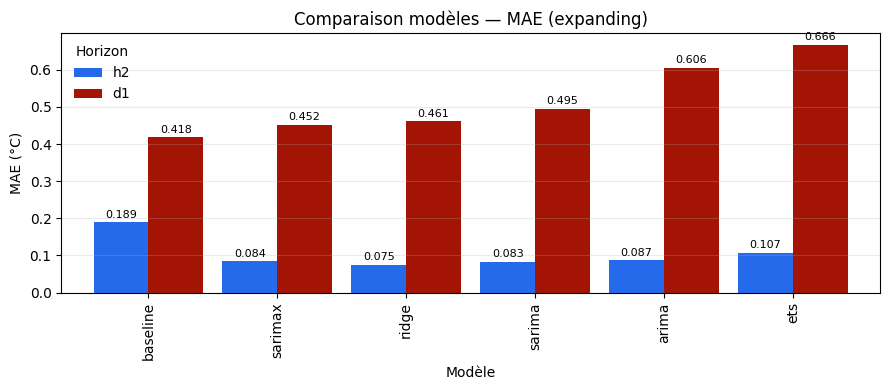

In [21]:
plot_df = cmp_exp[["model", "horizon", "mae"]].copy()
plot_df["horizon"] = pd.Categorical(plot_df["horizon"], categories=["h2", "d1"], ordered=True)

pivot = plot_df.pivot(index="model", columns="horizon", values="mae")

pivot = pivot.loc[pivot["d1"].sort_values().index]

colors_h = {"h2": "#256aeb", "d1": "#a31404"}  
bar_colors = [colors_h[h] for h in pivot.columns]

fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot(kind="bar", ax=ax, color=bar_colors, width=0.85)

ax.set_title("Comparaison modèles — MAE (expanding)")
ax.set_xlabel("Modèle")
ax.set_ylabel("MAE (°C)")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(title="Horizon", frameon=False)

for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2, fontsize=8)

fig.tight_layout()
plt.show()

### 4.2 — Visualisation prévision vs réel (courbes)

Pour compléter l’éval quantitative, on trace des courbes **réel vs prévision** sur la période de **validation** (2018-01 → 2018-06), pour une station représentative (817) et un horizon donné (ici **d1**).  
Les prédictions sont générées en **walk-forward** (utilisation du passé uniquement), avec des origines **densifiées** (≈ 1/jour) pour obtenir une figure lisible.  
Ces figures sont **illustratives/diagnostiques** ; la comparaison et la sélection des modèles restent basées sur le **backtesting fold-origin** (Section 4).

In [ ]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
from src.continuous_forecast import (
    predict_continuous_sarima,
    predict_continuous_sarimax,
    predict_continuous_ridge,
    predict_continuous_ets_refit,
    plot_pred_vs_true)
warnings.filterwarnings(
    "ignore",
    category=ValueWarning,
    message="No frequency information was provided, so inferred frequency")

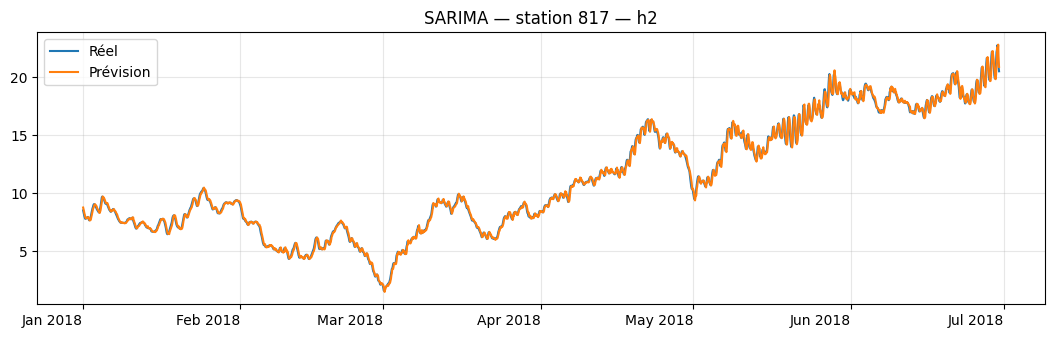

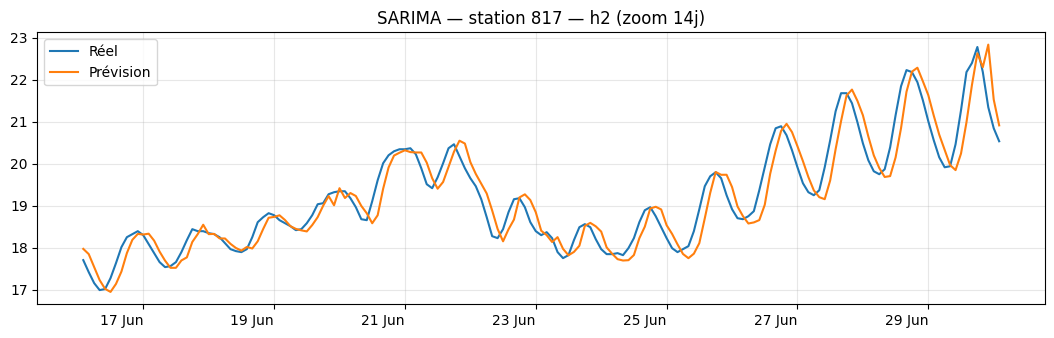

In [58]:
station = 817
start = "2018-01-01"
end   = "2018-06-30"
horizon = "h2"  
STRIDE = 1       


# SARIMA
pred_sarima = predict_continuous_sarima(
    df=df_model, station_id=station,
    start=start, end=end,
    ts_col=TS_COL, id_col=ID_COL, y_col=TARGET,
    horizon=horizon,
    order=(1,0,1), seasonal_order=(1,0,1,12),
    max_train_days=365,
    stride_steps=STRIDE,
    force_2h_freq=False
)
plot_pred_vs_true(pred_sarima, f"SARIMA — station {station} — {horizon}", zoom_days=14)



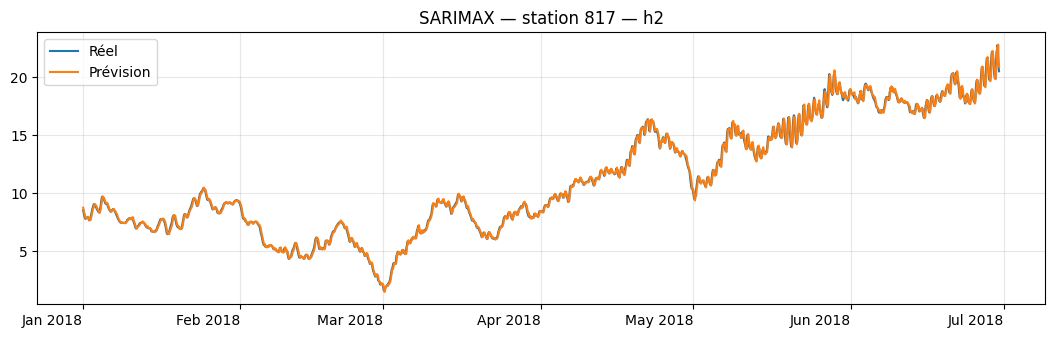

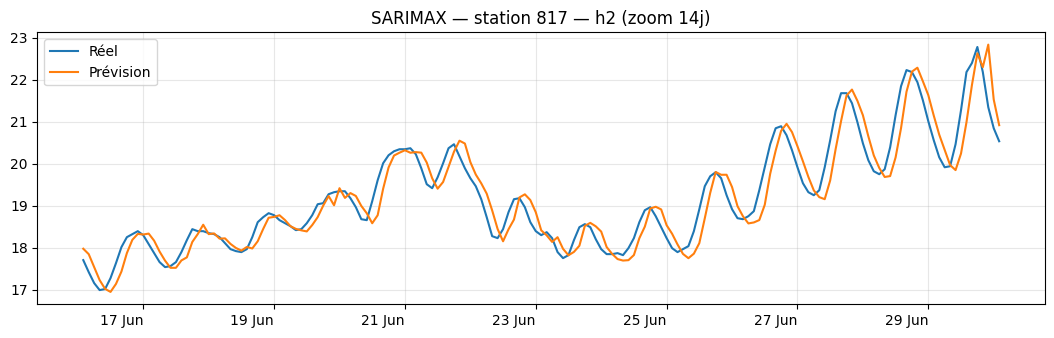

In [51]:
# SARIMAX (exog)
pred_sarimax = predict_continuous_sarimax(
    df=df_model, station_id=station,
    start=start, end=end,
    ts_col=TS_COL, id_col=ID_COL, y_col=TARGET,
    horizon=horizon,
    order=(1,0,1), seasonal_order=(1,0,1,12),
    exog_cols=["temp_air_eobs_c", "rainf_eobs"],
    max_train_days=365,
    stride_steps=STRIDE,
    force_2h_freq=False
)
plot_pred_vs_true(pred_sarimax, f"SARIMAX — station {station} — {horizon}", zoom_days=14)

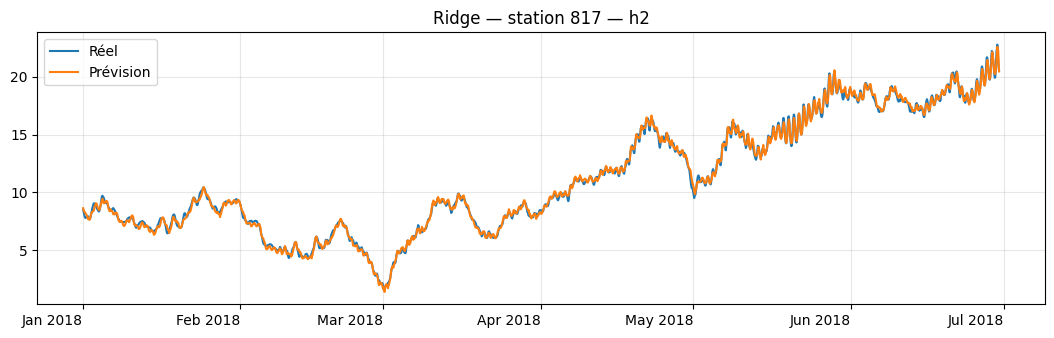

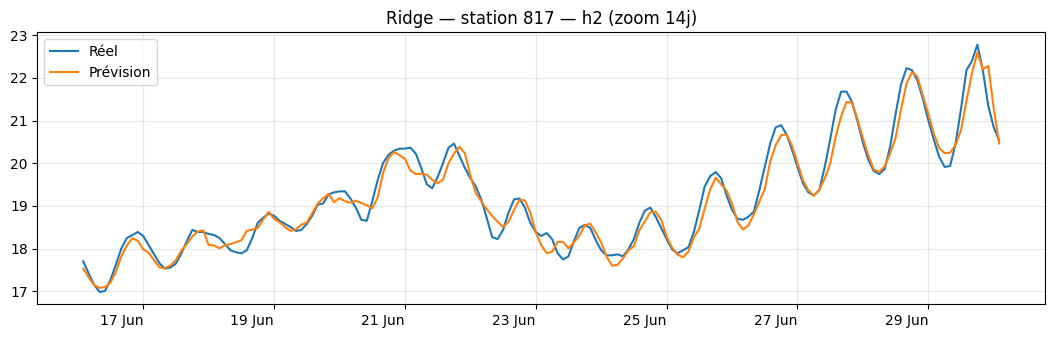

In [52]:
# Ridge
pred_ridge = predict_continuous_ridge(
    df=df_model, station_id=station,
    start=start, end=end,
    ts_col=TS_COL, id_col=ID_COL, y_col=TARGET,
    horizon=horizon,
    exog_cols=["temp_air_eobs_c", "rainf_eobs"],  
    max_train_days=365,
    alpha=1.0,
    standardize=True
)
plot_pred_vs_true(pred_ridge, f"Ridge — station {station} — {horizon}", zoom_days=14)

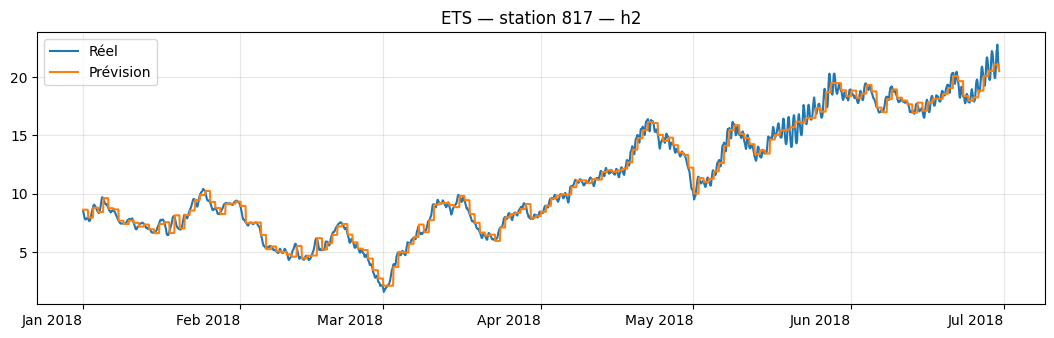

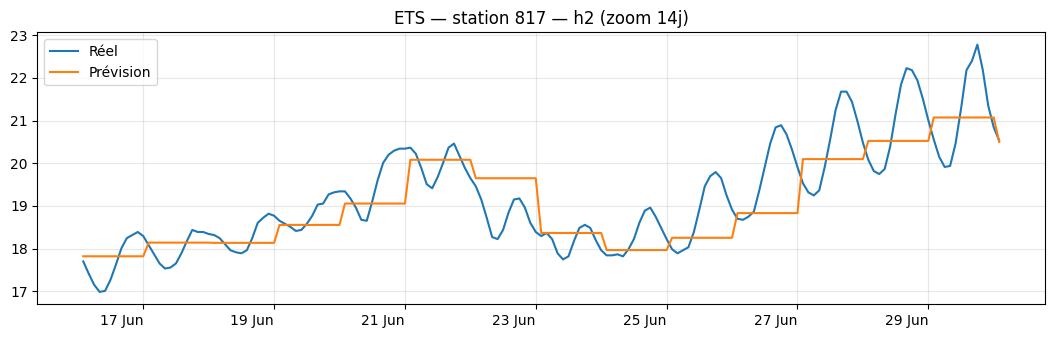

In [62]:
# ETS 
pred_ets = predict_continuous_ets_refit(
    df=df_model, station_id=station,
    start=start, end=end,
    ts_col=TS_COL, id_col=ID_COL, y_col=TARGET,
    horizon=horizon,
    max_train_days=365,
    seasonal_periods=12,
    refit_every_steps=12,  
    stride_steps=STRIDE,
    force_2h_freq=False
)
plot_pred_vs_true(pred_ets, f"ETS — station {station} — {horizon}", zoom_days=14)

In [ ]:
# SAVE ranking

cmp_exp.to_csv(ART_06_TBL / "cmp_exp_h2_d1.csv", index=False)
tbl_h2.to_csv(ART_06_TBL / "rank_h2.csv", index=False)
tbl_d1.to_csv(ART_06_TBL / "rank_d1.csv", index=False)

# SAVE preds
pred_sarima.to_csv(ART_06_PRD / f"pred_cont_sarima_{station}_{horizon}.csv", index=False)
pred_sarimax.to_csv(ART_06_PRD / f"pred_cont_sarimax_{station}_{horizon}.csv", index=False)
pred_ridge.to_csv(ART_06_PRD / f"pred_cont_ridge_{station}_{horizon}.csv", index=False)
pred_ets.to_csv(ART_06_PRD / f"pred_cont_ets_{station}_{horizon}.csv", index=False)

print(ART_06_TBL)
print( ART_06_PRD)

C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\tables
C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\predictions


## 5. **Sélection des meilleurs modèles (validation, fold-origin — mode expanding)**  
- **Horizon h2 (2h)** : meilleur modèle = **Ridge** (MAE = **0.0746**), devant SARIMA (0.0829) et SARIMAX (0.0838).  
- **Horizon d1 (24h)** : meilleur score = **Baseline saisonnière** (MAE = **0.4177**). Parmi les modèles “apprenants”, le meilleur est **SARIMAX** (MAE = **0.4520**), puis Ridge (0.4610).  

Pour la suite (Notebook 07), on retient **Ridge pour h2** et, pour d1, on retient **Baseline comme référence** et **SARIMAX comme candidat principal** à tuner et tester.

In [ ]:
selected = {
  "selection_basis": {
    "split": "val",
    "cv": "fold-origin",
    "mode": "expanding",
    "primary_metric": "mae",
    "n_preds_per_model_horizon": 84
  },
  "h2": {
    "winner": "ridge",
    "mae": 0.074631,
    "candidates": [
      {"model": "ridge", "mae": 0.074631},
      {"model": "sarima", "mae": 0.082907},
      {"model": "sarimax", "mae": 0.083805}
    ],
    "tuning_plan": {
      "do_tune": True,
      "params_to_tune": {
        "alpha": [0.1, 0.3, 1.0, 3.0, 10.0]
      },
      "final_candidate_for_test": "ridge"
    }
  },
  "d1": {
    "winner_overall": "baseline",
    "mae_winner": 0.41769,
    "best_learned_model": "sarimax",
    "mae_best_learned": 0.451987,
    "candidates": [
      {"model": "baseline", "mae": 0.41769},
      {"model": "sarimax", "mae": 0.451987},
      {"model": "ridge", "mae": 0.460987}
    ],
    "tuning_plan": {
      "do_tune": True,
      "note": "Baseline is kept as fixed reference; tune SARIMAX to try to beat baseline on TEST.",
      "sarimax": {
        "exog_cols": ["temp_air_eobs_c", "rainf_eobs"],
        "order_grid": [[1,0,1],[2,0,1],[1,0,2],[2,0,2]],
        "seasonal_order_grid": [[1,0,1,12],[1,0,2,12],[2,0,1,12]]
      },
      "final_candidate_for_test": "sarimax"
    }
  }
} 
with open(ART_06_SUM / "selected_models.json", "w", encoding="utf-8") as f:
    json.dump(selected, f, ensure_ascii=False, indent=2)
print("Saved:", ART_06_SUM / "selected_models.json")

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\summary\selected_models.json
